# Exploring and Modeling the Titanic Dataset

This notebook organizes into cells the same workflow developed in the course scripts. We will load and inspect the CSV file, separate inputs from the target, prepare numerical and categorical features, train a decision tree, evaluate its errors, and save the complete pipeline.

Run the cells in the visible order. When you finish, restart the kernel and select **Run All**. If the notebook runs from an empty kernel, its outputs do not depend on variables created outside the order shown here.


## 1. Checking the Environment

The kernel must use the same Python environment in which pandas, scikit-learn, matplotlib, and joblib are installed. The path and versions below make it easier to identify a kernel selected by mistake.


In [1]:
import sys

import joblib
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

print(f"Interpreter: {sys.executable}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib: {matplotlib.__version__}")


Interpreter: C:\Program Files\Python314\python.exe
pandas: 3.0.1
scikit-learn: 1.9.0
matplotlib: 3.10.8


## 2. Loading and Checking the CSV File

The `titanic.csv` file must be in the same folder as this notebook. The dataset uses `?` to mark some missing values, so we identify that marker while loading the file. The expected shape is 1,309 rows and 15 columns.


In [2]:
# na_values="?" converts the missing-value marker into values recognized by pandas.
data = pd.read_csv("titanic.csv", na_values="?")

print(f"Dataset shape: {data.shape}")
print("First five rows of the columns we will use:")
print(
    data[
        ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "survived"]
    ].head()
)


Dataset shape: (1309, 15)
First five rows of the columns we will use:
   pclass     sex      age  sibsp  parch      fare embarked  survived
0       1  female  29.0000      0      0  211.3375        S         1
1       1    male   0.9167      1      2  151.5500        S         1
2       1  female   2.0000      1      2  151.5500        S         0
3       1    male  30.0000      1      2  151.5500        S         0
4       1  female  25.0000      1      2  151.5500        S         0


## 3. Separating Features and Target

The seven features are the pieces of information provided to the model. The `survived` target is the answer the tree will learn to predict. It stays outside `X` so that the correct answer cannot be used as an input.


In [3]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target = "survived"

X = data[features]
y = data[target]

print(f"X shape: {X.shape}")
print(f"Number of target values in y: {len(y)}")
print("Target distribution:")
print(y.value_counts().sort_index())


X shape: (1309, 7)
Number of target values in y: 1309
Target distribution:
survived
0    809
1    500
Name: count, dtype: int64


## 4. Creating Training and Test Sets

The training set is used to learn means, modes, categories, and tree splits. The test set remains separate so that we can measure the pipeline's behavior on rows that did not participate in training. `stratify=y` preserves similar class proportions in both sets.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")
print(f"Proportion of class 1 in training: {y_train.mean():.4f}")
print(f"Proportion of class 1 in testing: {y_test.mean():.4f}")


Training rows: 1047
Test rows: 262
Proportion of class 1 in training: 0.3820
Proportion of class 1 in testing: 0.3817


## 5. Preparing Numerical and Categorical Features

Missing values in numerical columns receive the mean calculated only from the training set. In categorical columns, we use the most frequent category and then create numerical indicators with one-hot encoding. The `ColumnTransformer` applies each preprocessing flow to the correct group of columns.


In [5]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

# The mode and the known categories are learned only when fit() receives X_train.
categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "one_hot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="mean"), numeric_features),
        ("categorical", categorical_preprocessor, categorical_features),
    ]
)

print("Preprocessor configured for 5 numerical and 2 categorical features.")


Preprocessor configured for 5 numerical and 2 categorical features.


## 6. Training the Decision Tree

The tree uses entropy to compare possible splits and has a maximum depth of 3. The pipeline keeps preprocessing and the model together, so `fit()` learns every transformation using only the training set.


In [6]:
tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42,
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", tree_model),
    ]
)

# fit() first adjusts preprocessing and then trains the tree.
model_pipeline.fit(X_train, y_train)

print("Pipeline trained successfully.")


Pipeline trained successfully.


## 7. Evaluating Correct Predictions and Error Types

The pipeline now transforms the test set with the rules learned from the training set and produces one prediction for each row. The matrix follows the order `[[TN, FP], [FN, TP]]`. Precision, recall, and F1 reorganize these four counts to answer different questions.


In [7]:
test_predictions = model_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions, zero_division=0)
test_recall = recall_score(y_test, test_predictions, zero_division=0)
test_f1 = f1_score(y_test, test_predictions, zero_division=0)
test_matrix = confusion_matrix(y_test, test_predictions)

print(f"Accuracy: {test_accuracy:.3f}")
print(f"Precision: {test_precision:.3f}")
print(f"Recall: {test_recall:.3f}")
print(f"F1: {test_f1:.3f}")
print("Confusion matrix:")
print(test_matrix)


Accuracy: 0.836
Precision: 0.813
Recall: 0.740
F1: 0.775
Confusion matrix:
[[145  17]
 [ 26  74]]


## 8. Comparing the Model with a Simple Reference

Because class 0 is more frequent, a strategy that always predicts 0 already classifies many rows correctly. This baseline does not use any feature. The comparison shows how much the pipeline improves over this starting point.


In [8]:
baseline_predictions = [0] * len(y_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_matrix = confusion_matrix(y_test, baseline_predictions)

print(f"Baseline accuracy: {baseline_accuracy:.3f}")
print("Baseline confusion matrix:")
print(baseline_matrix)


Baseline accuracy: 0.618
Baseline confusion matrix:
[[162   0]
 [100   0]]


## 9. Inspecting Incorrect Examples

The metrics summarize the entire test set. To investigate concrete errors, we add the actual and predicted classes to the test features. Here we display up to three false positives and three false negatives without changing the model.


In [9]:
evaluated_cases = X_test.copy()
evaluated_cases["actual"] = y_test
evaluated_cases["predicted"] = test_predictions

false_positives = evaluated_cases[
    (evaluated_cases["actual"] == 0) & (evaluated_cases["predicted"] == 1)
]
false_negatives = evaluated_cases[
    (evaluated_cases["actual"] == 1) & (evaluated_cases["predicted"] == 0)
]

columns_to_show = ["pclass", "sex", "age", "fare", "actual", "predicted"]

print("False positives:")
print(false_positives[columns_to_show].head(3))
print("\nFalse negatives:")
print(false_negatives[columns_to_show].head(3))


False positives:
      pclass     sex   age  fare  actual  predicted
975        3  female  26.0  16.1       0          1
1263       3    male  11.5  14.5       0          1
1153       3  female  47.0  14.5       0          1

False negatives:
      pclass     sex   age     fare  actual  predicted
1028       3  female   NaN  24.1500       1          0
1121       3    male   NaN  22.3583       1          0
20         1    male  37.0  52.5542       1          0


## 10. Visualizing the Trained Tree

We extract the fitted tree and the transformed column names from the pipeline. The figure uses the exact model that produced the previous predictions. Internal node IDs are not displayed; follow the conditions and feature names to read the tree.


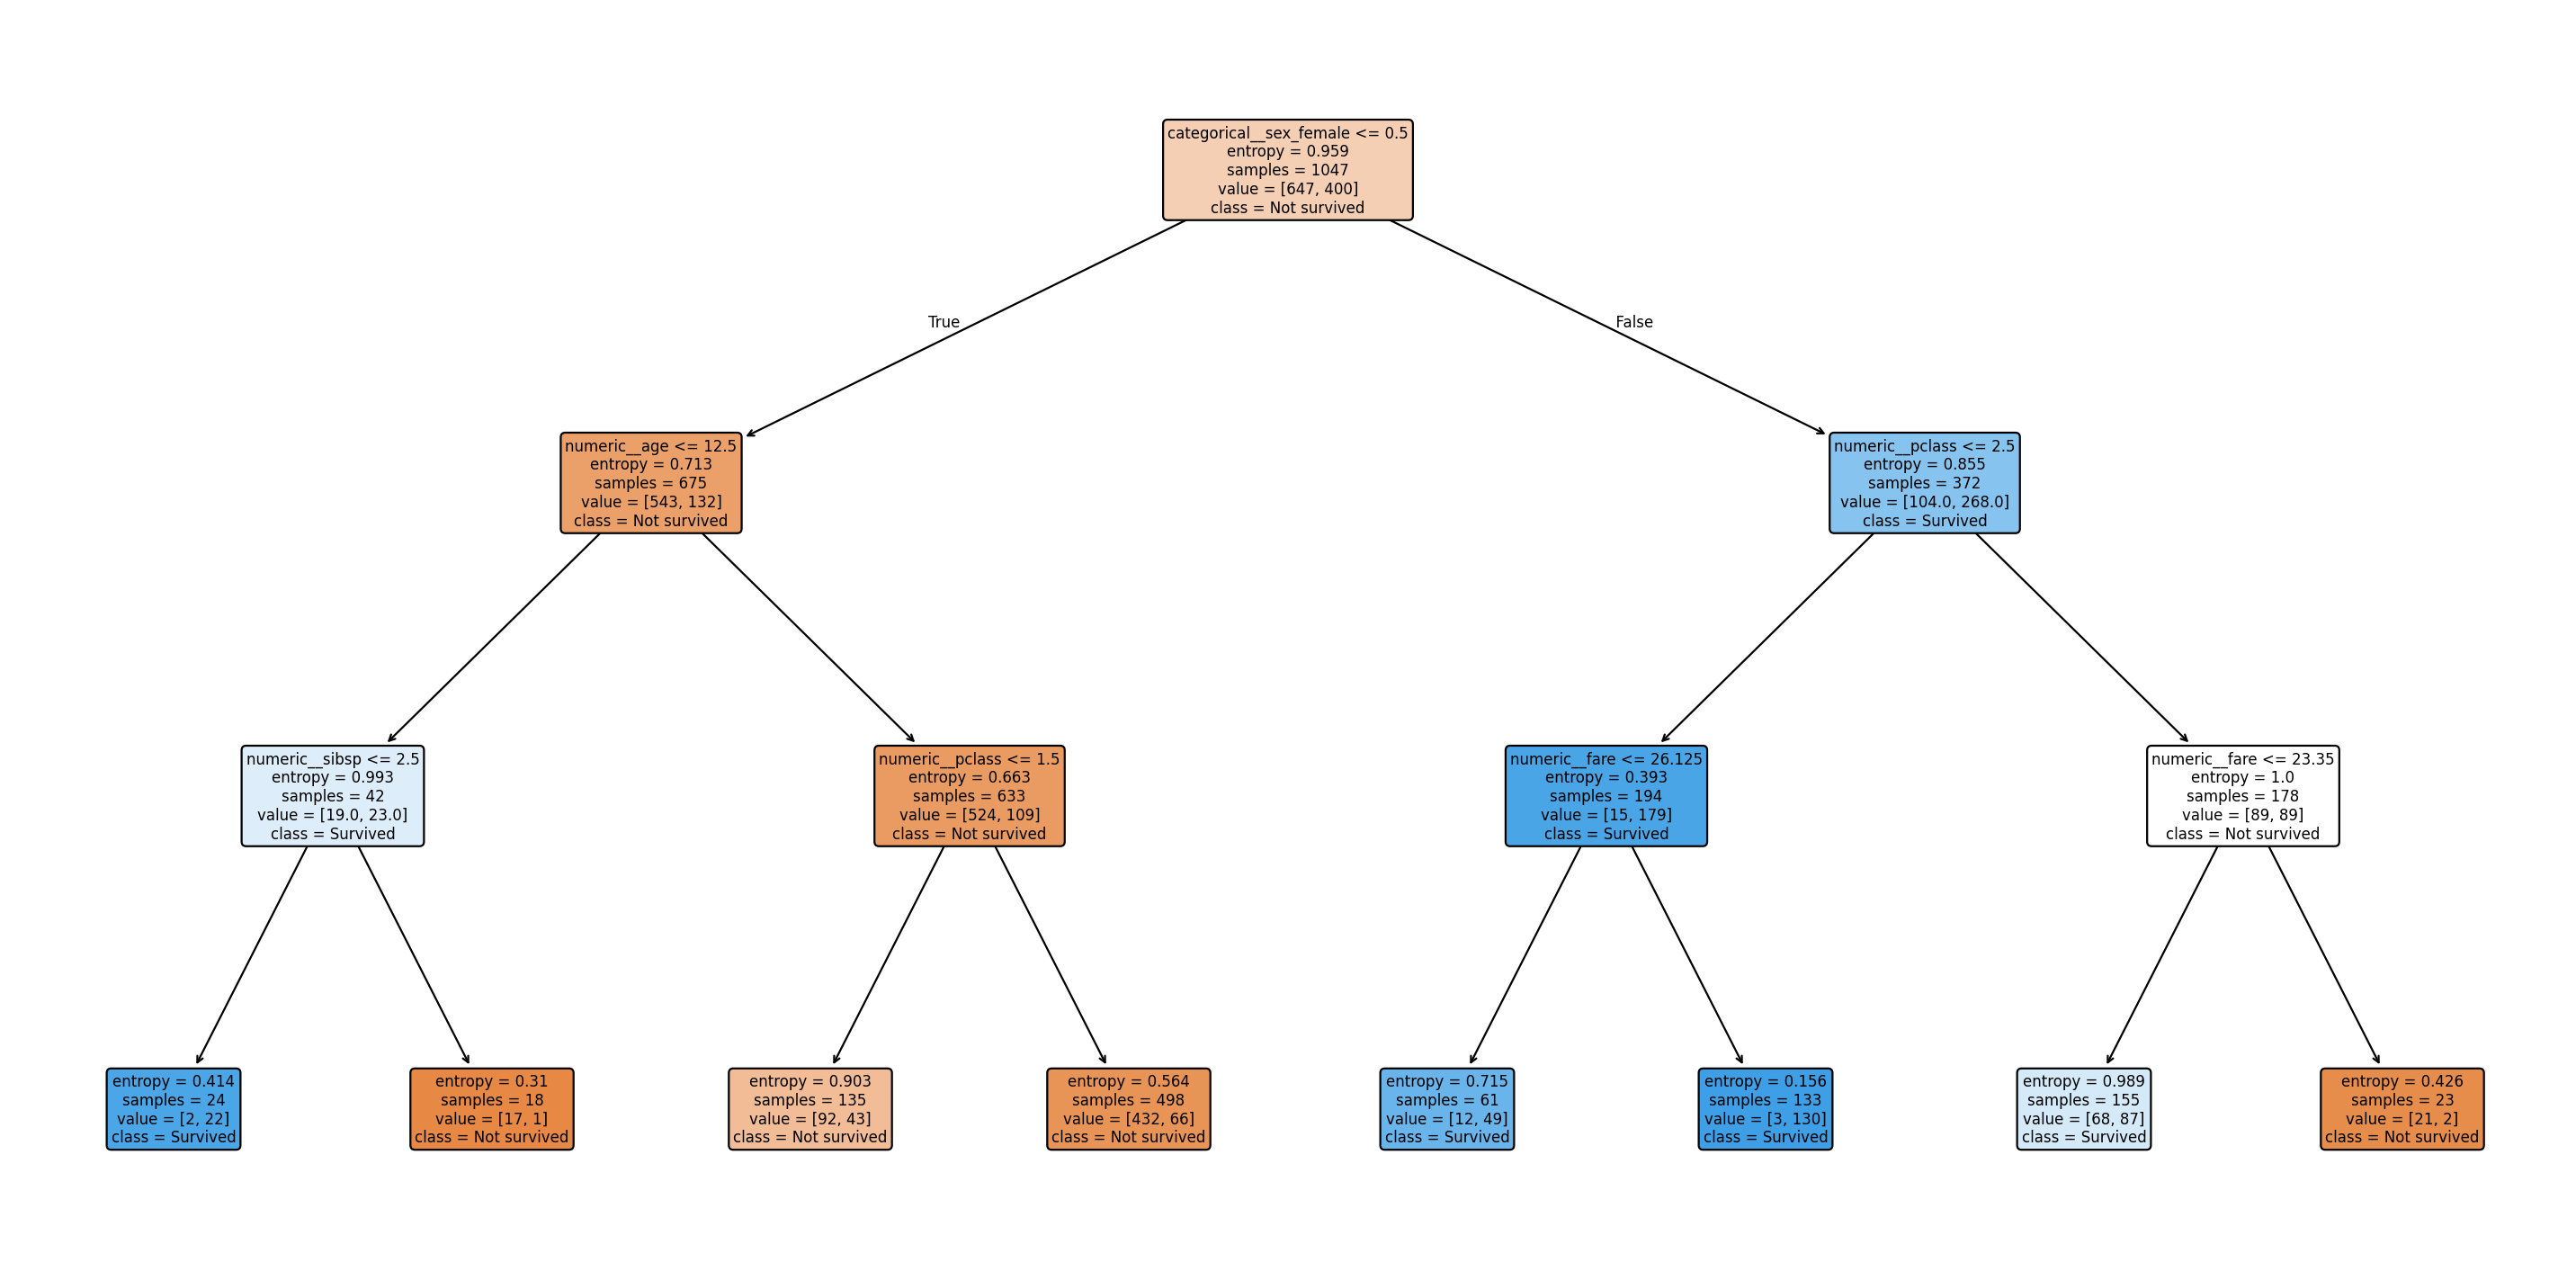

Image saved as titanic_tree.png


In [10]:
trained_preprocessor = model_pipeline.named_steps["preprocessor"]
trained_tree = model_pipeline.named_steps["model"]
transformed_feature_names = trained_preprocessor.get_feature_names_out()

plt.figure(figsize=(18, 9))
plot_tree(
    trained_tree,
    feature_names=transformed_feature_names,
    class_names=["Not survived", "Survived"],
    filled=True,
    rounded=True,
)
plt.tight_layout()
plt.savefig("titanic_tree.png", dpi=160, bbox_inches="tight")
plt.show()

print("Image saved as titanic_tree.png")


## 11. Predicting a New Row

The new input uses the same seven columns and the same names as `X`. `predict()` applies the fitted preprocessing steps and then traverses the tree. Class 0 means "not survived," and class 1 means "survived."


In [11]:
new_passenger = pd.DataFrame(
    {
        "pclass": [2],
        "sex": ["male"],
        "age": [30],
        "sibsp": [0],
        "parch": [0],
        "fare": [12.5],
        "embarked": ["C"],
    }
)

new_prediction = int(model_pipeline.predict(new_passenger)[0])
new_label = "survived" if new_prediction == 1 else "not survived"

print(f"Predicted class: {new_prediction}")
print(f"Interpretation: {new_label}")


Predicted class: 0
Interpretation: not survived


## 12. Saving and Reloading the Pipeline

We save the entire pipeline because the tree depends on the means, modes, categories, and column order learned by the preprocessor. After reloading the file, we repeat the prediction to verify that the artifact preserved this contract.


In [12]:
pipeline_filename = "titanic_pipeline.joblib"
joblib.dump(model_pipeline, pipeline_filename)

loaded_pipeline = joblib.load(pipeline_filename)
loaded_prediction = int(loaded_pipeline.predict(new_passenger)[0])

print(f"Pipeline saved as {pipeline_filename}")
print(f"Prediction after reloading: {loaded_prediction}")
print(f"Predictions match: {loaded_prediction == new_prediction}")


Pipeline saved as titanic_pipeline.joblib
Prediction after reloading: 0
Predictions match: True


## Conclusion

The notebook reproduced the complete workflow from the CSV file: it checked the data, separated training and test sets, fitted preprocessing only on the training set, trained the tree, evaluated its errors, and saved the pipeline. Restarting the kernel and selecting **Run All** should rebuild the same metrics, image, and prediction without relying on hidden state.
